**Проектная работа по моделированию ключевой ставки ЦБ**

При моделировании использовался набор данных, содержащих в себе показатели инфляции, цены за нефть Urals, безработицы, ВВП за текущий период,
изменение зарубежных инвестиций, процента экспорта в ВВП и курса валюты. Для преведения показателей "в одно измерение" было проведено логарифмирование.
Выбросы в данном датасете были проигнорированы, чтобы понять реакцию Центрального Банка на конкретную ситуацию. Категориальные признаки отсутствуют.

Первые 5 строк данных:
   Rate  Inflation  ln Urals  Unemployment     ln GDP  Foreign Invest   \
0   5.5       6.14  4.672829         0.053  10.178555         3.019402   
1   5.5       6.27  4.667957         0.055  10.178555         3.019402   
2   5.5       6.50  4.707004         0.054  10.178555         3.019402   
3   5.5       6.47  4.689052         0.056  10.178555         3.019402   
4   5.5       6.07  4.675722         0.056  10.168048         1.069876   

   Export GDP  ln USDRUB  
0   25.845337   3.486733  
1   25.845337   3.469992  
2   25.845337   3.485531  
3   25.845337   3.494900  
4   27.111097   3.528703  

Пропущенные значения:
Rate               0
Inflation          0
ln Urals           0
Unemployment       0
ln GDP             0
Foreign Invest     0
Export GDP         0
ln USDRUB          0
dtype: int64

Форма данных после подготовки:
Обучающая выборка: (99, 7), (99,)
Тестовая выборка: (25, 7), (25,)


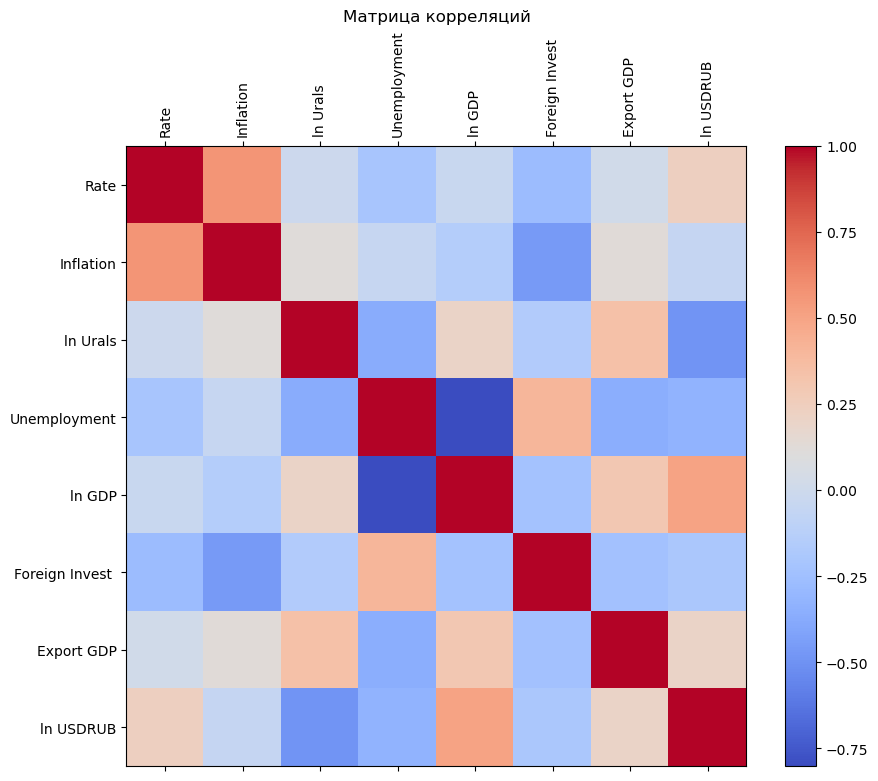

In [12]:
import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# 1. Загрузка данных
try:
    data = pd.read_excel(r'C:\Users\Heartpiercer.music\Desktop\ML_rate2.xlsx')  
except:
    data = pd.read_csv('ML_rate2.csv')  

print("Первые 5 строк данных:")
print(data.head())

# 2. Проверка пропущенных значений
print("\nПропущенные значения:")
print(data.isnull().sum())

# 3. Заполнение пропущенных значений (KNN Imputer)
if data.isnull().sum().any():
    imputer = KNNImputer(n_neighbors=3)
    data_imputed = imputer.fit_transform(data.select_dtypes(include=[np.number]))
    data.update(pd.DataFrame(data_imputed, columns=data.select_dtypes(include=[np.number]).columns))
    print("\nПропуски заполнены методом KNN.")

# 4. Масштабирование числовых признаков
scaler = StandardScaler()
numerical_cols = data.select_dtypes(include=[np.number]).columns
data_scaled = scaler.fit_transform(data[numerical_cols])
data_scaled = pd.DataFrame(data_scaled, columns=numerical_cols)

# 5. Разделение на обучающую и тестовую выборки
X = data_scaled.drop('Rate', axis=1)
y = data_scaled['Rate']  # Или data['Rate'] если не масштабировали целевую переменную
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)

print("\nФорма данных после подготовки:")
print(f"Обучающая выборка: {X_train.shape}, {y_train.shape}")
print(f"Тестовая выборка: {X_test.shape}, {y_test.shape}")

# 6. Дополнительный анализ (корреляция)
corr_matrix = data.corr()
plt.figure(figsize=(10, 8))
plt.matshow(corr_matrix, cmap='coolwarm', fignum=1)
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.colorbar()
plt.title("Матрица корреляций")
plt.show()

# 7. Сохранение подготовленных данных
prepared_data = {
    'X_train': X_train,
    'X_test': X_test,
    'y_train': y_train,
    'y_test': y_test,
    'scaler': scaler
}

Из предварительного корреляционного анализа видно, что показатели ВВП и безработицы сильно коррелируют. Это объясняется тем, что
при росте ВВП задействуются все ресурсы и безработица падает. И наоборот, в кризисные периоды менеджеры уволняют сотрудников, чтобы сократить расходы.

Создание взаимодействий между признаками...
Генерация полиномиальных признаков...
Преобразование признаков для снижения асимметрии...

Проверка стационарности (p-value):
Rate: 0.0294 ✅ Стационарный
Inflation: 0.4321 ❌ Нестационарный
ln Urals: 0.0477 ✅ Стационарный

Применение PCA...
Оригинальное количество признаков: 18
Количество главных компонент: 6

Проверка мультиколлинеарности...
Топ-10 признаков с наибольшим VIF:
                   Feature           VIF
9                 GDP_poly           inf
3                   ln GDP           inf
4          Foreign Invest            inf
1                 ln Urals           inf
10              Urals_poly           inf
11             Invest_poly           inf
12                  GDP_sq  3.218802e+08
8   GDP_Export_interaction  2.629217e+08
5               Export GDP  2.621016e+08
13                Urals_sq  6.277996e+07

Визуализация корреляционной матрицы...


C:\Users\Heartpiercer.music\anaconda3\Lib\site-packages\statsmodels\stats\outliers_influence.py:198: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


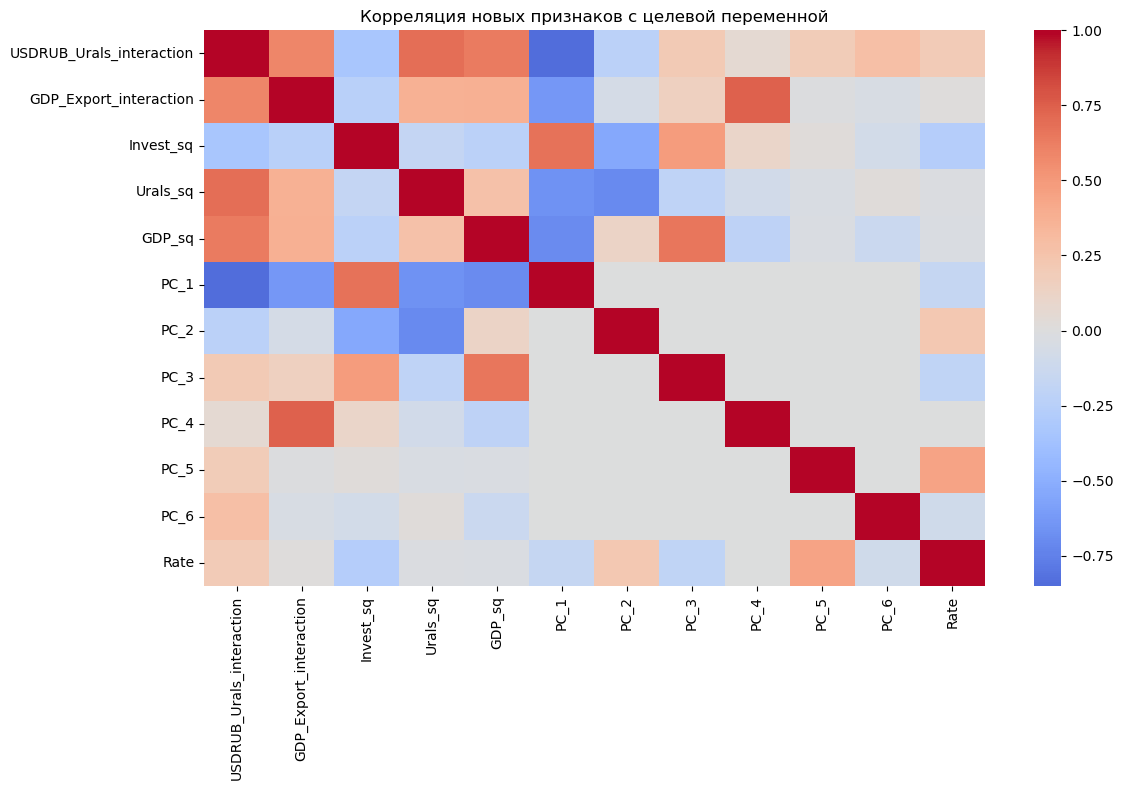


Готово! Датасет с новыми признаками сохранен в файл: None


,Rate,Inflation,ln Urals,Unemployment,ln GDP,Foreign Invest,Export GDP,ln USDRUB,USDRUB_Urals_interaction,GDP_Export_interaction,...,Invest_sq,GDP_Urals,GDP_Unemp,Urals_Invest,PC_1,PC_2,PC_3,PC_4,PC_5,PC_6
0,5.5,6.14,4.672829,0.053,10.178555,3.019402,25.845337,3.486733,16.292905,263.068189,...,30.733151,21.835329,14.109149,9.116789,1.833750,-5.730551,-0.380371,-1.804053,0.618125,-0.493576
1,5.5,6.27,4.667957,0.055,10.178555,3.019402,25.845337,3.469992,16.197776,263.068189,...,30.733151,21.789824,14.094440,9.116789,1.945395,-5.724806,-0.458795,-1.769758,0.584429,-0.546271
2,5.5,6.50,4.707004,0.054,10.178555,3.019402,25.845337,3.485531,16.406409,263.068189,...,30.733151,22.155891,14.212339,9.116789,1.736841,-5.895529,-0.472792,-1.804308,0.660013,-0.487741
3,5.5,6.47,4.689052,0.056,10.178555,3.019402,25.845337,3.494900,16.387768,263.068189,...,30.733151,21.987206,14.158133,9.116789,1.862409,-5.805442,-0.479979,-1.745628,0.650709,-0.454530
4,5.5,6.07,4.675722,0.056,10.168048,1.069876,27.111097,3.528703,16.499235,275.666929,...,10.878554,21.862375,5.002444,1.144636,-0.399893,-3.156363,-2.535698,-0.795671,-1.625833,-0.525944


In [2]:
import seaborn as sns
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.decomposition import PCA
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Загрузка данных
data = pd.read_excel(r'C:\Users\Heartpiercer.music\Desktop\ML_rate2.xlsx') 

# 1. Создание взаимодействий между признаками
print("Создание взаимодействий между признаками...")
data['USDRUB_Urals_interaction'] = data['ln USDRUB'] * data['ln Urals']
data['GDP_Export_interaction'] = data['ln GDP'] * data['Export GDP']

# 2. Генерация полиномиальных признаков
print("Генерация полиномиальных признаков...")
poly = PolynomialFeatures(degree=2, include_bias=False, interaction_only=False)
poly_features = poly.fit_transform(data[['ln GDP', 'ln Urals', 'Foreign Invest ']])
poly_columns = [
    'GDP_poly', 'Urals_poly', 'Invest_poly', 
    'GDP_sq', 'Urals_sq', 'Invest_sq',
    'GDP_Urals', 'GDP_Unemp', 'Urals_Invest'
]
poly_df = pd.DataFrame(poly_features, columns=poly_columns)
data = pd.concat([data, poly_df], axis=1)

# 3. Преобразования для снижения асимметрии
print("Преобразование признаков для снижения асимметрии...")
skewed_features = ['Foreign Invest', 'Export GDP']

# 4. Проверка стационарности (тест Дики-Фуллера)
print("\nПроверка стационарности (p-value):")
for col in ['Rate', 'Inflation', 'ln Urals']:
    result = adfuller(data[col].dropna())
    print(f"{col}: {result[1]:.4f} {'✅ Стационарный' if result[1] < 0.05 else '❌ Нестационарный'}")

# 5. Метод главных компонент (PCA)
print("\nПрименение PCA...")
numeric_cols = data.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols.remove('Rate')  # Исключаем целевую переменную

# Масштабирование данных
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data[numeric_cols])

# Применение PCA
pca = PCA(n_components=0.95)  # Сохраняем 95% дисперсии
pca_features = pca.fit_transform(scaled_data)
pca_df = pd.DataFrame(pca_features, columns=[f'PC_{i+1}' for i in range(pca_features.shape[1])])
data = pd.concat([data.reset_index(drop=True), pca_df], axis=1)

print(f"Оригинальное количество признаков: {len(numeric_cols)}")
print(f"Количество главных компонент: {pca.n_components_}")

# 6. Проверка мультиколлинеарности
print("\nПроверка мультиколлинеарности...")
vif_data = data[numeric_cols]

# Расчет VIF для каждого признака
vif = pd.DataFrame()
vif["Feature"] = vif_data.columns
vif["VIF"] = [variance_inflation_factor(vif_data.values, i) for i in range(vif_data.shape[1])]

print("Топ-10 признаков с наибольшим VIF:")
print(vif.sort_values("VIF", ascending=False).head(10))

# 7. Визуализация корреляционной матрицы
print("\nВизуализация корреляционной матрицы...")
new_features = [
    'USDRUB_Urals_interaction', 'GDP_Export_interaction',
    'Invest_sq','Urals_sq',  'GDP_sq',
    'PC_1', 'PC_2', 'PC_3', 'PC_4', 'PC_5', 'PC_6', 'Rate'
]

plt.figure(figsize=(12, 8))
corr_matrix = data[new_features].corr()
sns.heatmap(corr_matrix, fmt=".2f", cmap='coolwarm', center=0)
plt.title("Корреляция новых признаков с целевой переменной")
plt.tight_layout()
plt.show()

# 8. Сохранение результата
output_path = data.to_excel(r'C:\Users\Heartpiercer.music\Desktop\ML_rate2_with_new_features.xlsx', index=False)
print(f"\nГотово! Датасет с новыми признаками сохранен в файл: {output_path}")
data.head()

Были созданы признаки характеризующие взаимодействие между переменными. Так, изначальная цена Urals была выражена в долларах, и 
при перемножении ее на курс доллара мы понимаем, какая сумма попадет в бюджет в виде налогов в рублях на баррель нефти.
При перемножении цены Urals на процент ВВП мы понимаем сколько будет занимать в составе ВВП один баррель нефти. Создана матрица корреляций, результаты которой будут учитываться при создании моделей.


Анализ корреляции с целевой переменной:


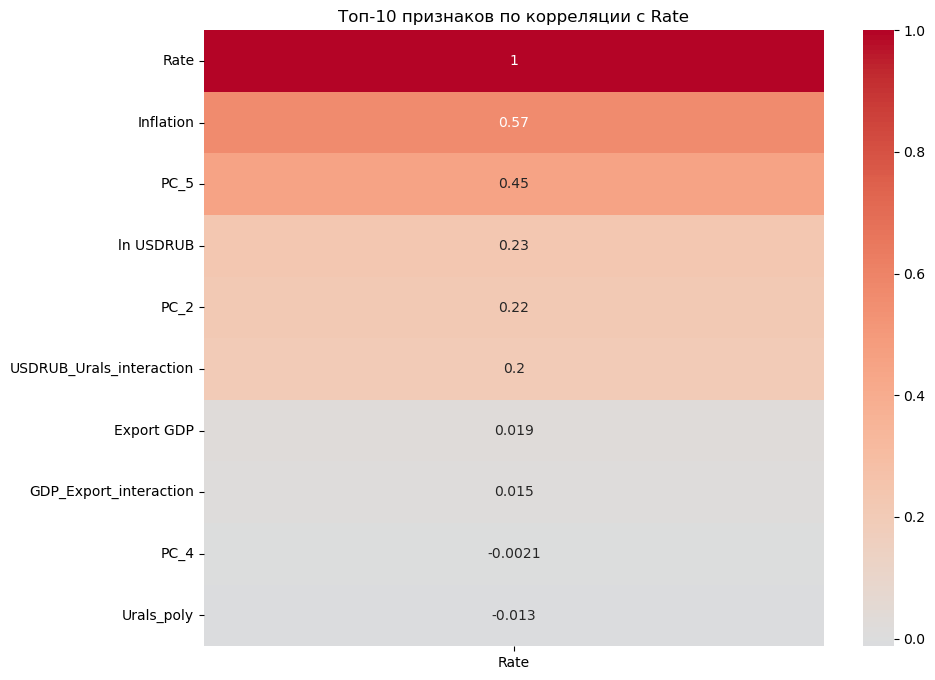


Статистическая значимость признаков:
Топ-5 признаков по абсолютной корреляции Пирсона:
            Feature   Pearson  Spearman  abs_Pearson  abs_Spearman  \
0         Inflation  0.567776  0.532170     0.567776      0.532170   
22             PC_5  0.447147  0.431183     0.447147      0.431183   
16        GDP_Unemp -0.297135 -0.251984     0.297135      0.251984   
14        Invest_sq -0.270585 -0.275995     0.270585      0.275995   
4   Foreign Invest  -0.269164 -0.249011     0.269164      0.249011   

    Pearson_pval  Spearman_pval  
0   6.126000e-12   2.006536e-10  
22  1.926805e-07   5.751221e-07  
16  8.044411e-04   4.753663e-03  
14  2.369725e-03   1.917484e-03  
4   2.503507e-03   5.289429e-03  

Отбор признаков методами фильтрации:
Топ-5 признаков по Mutual Information:
                   Feature  MI_score
9                 GDP_poly  1.034357
11             Invest_poly  0.974467
14               Invest_sq  0.974371
4          Foreign Invest   0.972672
8   GDP_Export_interactio

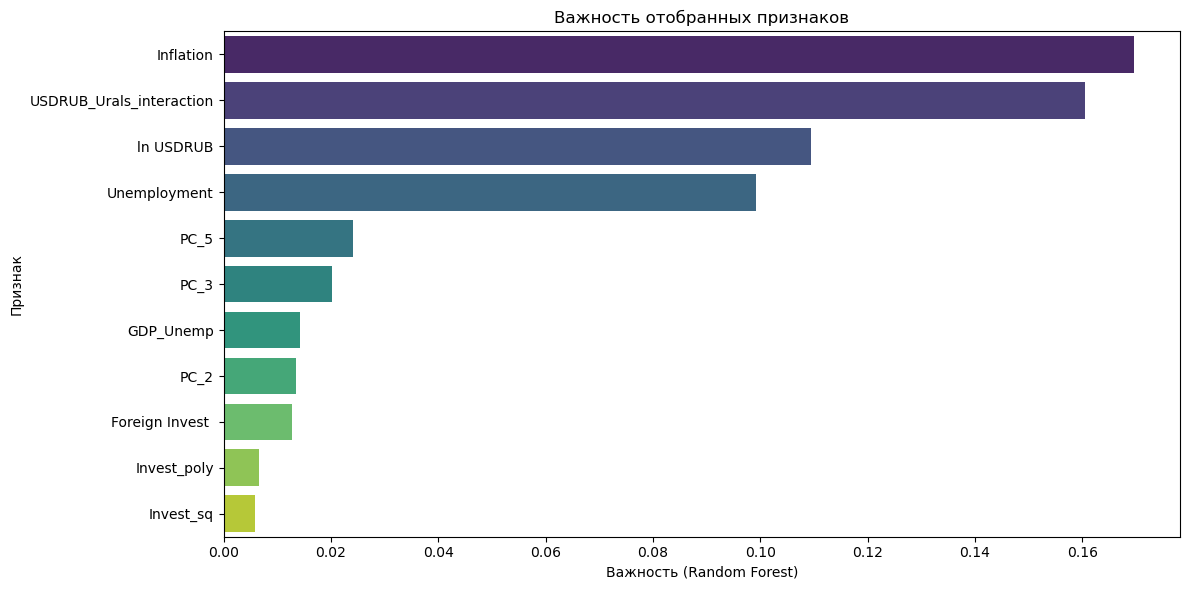


Отобранные признаки сохранены в файл 'ML_rate2_selected_features.xlsx'


In [3]:
from scipy import stats
from sklearn.feature_selection import (SelectKBest, mutual_info_regression, 
                                     RFE, f_regression)
from sklearn.linear_model import LassoCV, LinearRegression
from sklearn.ensemble import RandomForestRegressor
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.anova import anova_lm
from statsmodels.formula.api import ols

# Загрузка данных с новыми признаками
data = pd.read_excel(r'C:\Users\Heartpiercer.music\Desktop\ML_rate2_with_new_features.xlsx')
X = data.drop('Rate', axis=1)
y = data['Rate']

# 1. Корреляционный анализ
print("Анализ корреляции с целевой переменной:")
corr_matrix = data.corr()
target_corr = corr_matrix['Rate'].sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix.loc[target_corr.index[:10], ['Rate']], 
            annot=True, cmap='coolwarm', center=0)
plt.title("Топ-10 признаков по корреляции с Rate")
plt.show()

# 2. Статистические тесты
print("\nСтатистическая значимость признаков:")
# Для числовых признаков
numeric_features = X.select_dtypes(include=[np.number]).columns
stat_results = []

for feature in numeric_features:
    pearson = stats.pearsonr(X[feature], y)[0]
    spearman = stats.spearmanr(X[feature], y)[0]
    stat_results.append({
        'Feature': feature,
        'Pearson': pearson,
        'Spearman': spearman,
        'abs_Pearson': abs(pearson),
        'abs_Spearman': abs(spearman)
    })

stats_df = pd.DataFrame(stat_results)
stats_df['Pearson_pval'] = [stats.pearsonr(X[f], y)[1] for f in numeric_features]
stats_df['Spearman_pval'] = [stats.spearmanr(X[f], y)[1] for f in numeric_features]

print("Топ-5 признаков по абсолютной корреляции Пирсона:")
print(stats_df.sort_values('abs_Pearson', ascending=False).head(5))

# 3. Методы фильтрации
print("\nОтбор признаков методами фильтрации:")
# Mutual Information
mi = SelectKBest(score_func=mutual_info_regression, k='all')
mi.fit(X[numeric_features], y)
mi_scores = pd.DataFrame({'Feature': numeric_features, 'MI_score': mi.scores_})
print("Топ-5 признаков по Mutual Information:")
print(mi_scores.sort_values('MI_score', ascending=False).head(5))

# 4. Методы обертывания (RFE)
print("\nRecursive Feature Elimination (RFE):")
estimator = LinearRegression()
rfe = RFE(estimator, n_features_to_select=5)
rfe.fit(X[numeric_features], y)
rfe_results = pd.DataFrame({
    'Feature': numeric_features,
    'RFE_ranking': rfe.ranking_,
    'RFE_support': rfe.support_
})
print("Лучшие 5 признаков по RFE:")
print(rfe_results[rfe_results['RFE_support']].sort_values('RFE_ranking'))


# Feature Importance from Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X[numeric_features], y)
rf_importance = pd.DataFrame({
    'Feature': numeric_features,
    'RF_importance': rf.feature_importances_
})
print("\nТоп-10 важных признаков по Random Forest:")
print(rf_importance.sort_values('RF_importance', ascending=False).head(10))

# 5. Итоговый отбор признаков
print("\nИтоговый отбор признаков:")

# Объединяем все метрики
feature_metrics = pd.merge(stats_df, mi_scores, on='Feature')
feature_metrics = pd.merge(feature_metrics, rfe_results, on='Feature')
feature_metrics = pd.merge(feature_metrics, rf_importance, on='Feature')
#feature_metrics = pd.merge(feature_metrics, vif, on='Feature')

# Фильтруем по критериям
selected_features = feature_metrics[
    (feature_metrics['abs_Pearson'] > 0.1) &
    (feature_metrics['Pearson_pval'] < 0.05)
].sort_values('RF_importance', ascending=False)

print("Отобранные признаки:")
print(selected_features[['Feature', 'Pearson', 'RF_importance']])

# Визуализация важности признаков
plt.figure(figsize=(12, 6))
sns.barplot(data=selected_features, x='RF_importance', y='Feature', palette='viridis')
plt.title('Важность отобранных признаков')
plt.xlabel('Важность (Random Forest)')
plt.ylabel('Признак')
plt.tight_layout()
plt.show()

# Сохранение отобранных признаков
selected_cols = selected_features['Feature'].tolist() + ['Rate']
selected_data = data[selected_cols]
selected_data.to_excel(r'C:\Users\Heartpiercer.music\Desktop\ML_rate2_with_new_features_2.xlsx', index=False)
print("\nОтобранные признаки сохранены в файл 'ML_rate2_selected_features.xlsx'")

Из всех полученных премененных необходимо выбрать те, которые коррелируют с ключевой ставкой в наибольшей степени, у которых отсутствует ярко выраженная автокорреляция и гетероскедастичность с другими переменными. Критерием отбора служила статистическая значимость по Пирсону. Она сообщает о том, имеется ли статистически значимая связь. Вторым критерием служила важность по случайному лесу. Отобраны наиболее значимые переменные.

Обучение Linear Regression...

Обучение Lasso Regression...

Обучение Ridge Regression...

Обучение Random Forest Regression...

Средние метрики по кросс-валидации:

Linear:
MSE: 1854862080265.4617
MAE: 508078.3408
R2: -7609690585592.9658

Lasso:
MSE: 20.0737
MAE: 3.7745
R2: -21.0598

Ridge:
MSE: 17.2629
MAE: 3.5265
R2: -17.5636

RandomForest:
MSE: 15.9452
MAE: 3.1589
R2: -8.7809


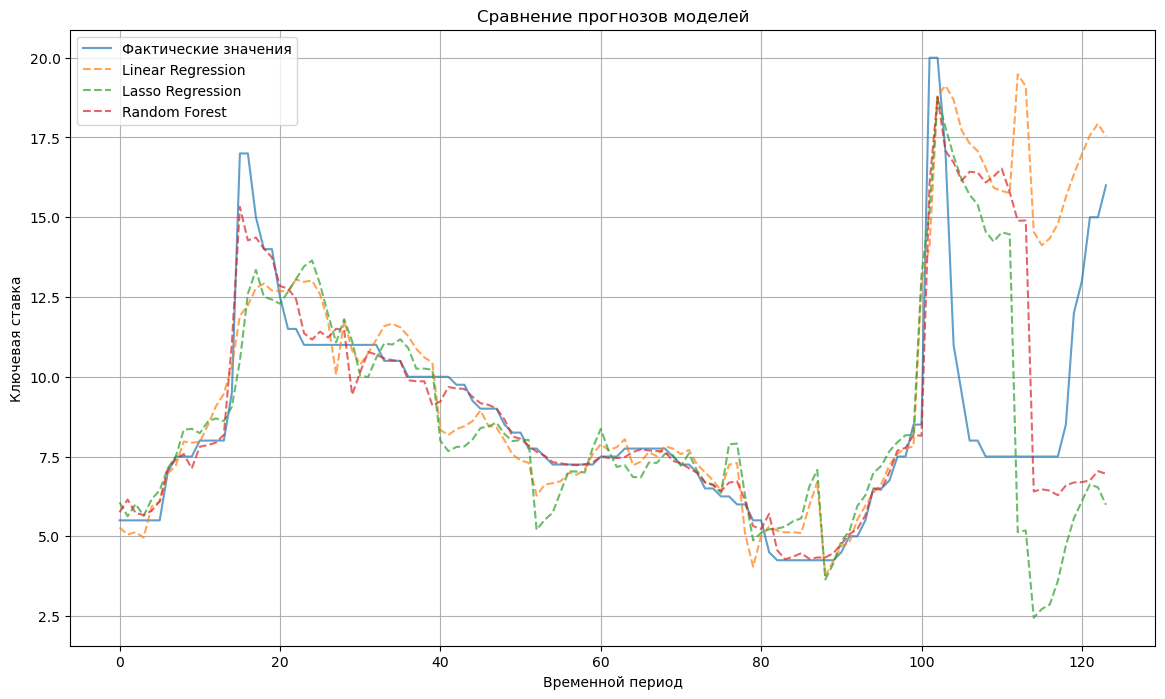


Все модели сохранены в файл 'rate_prediction_models.pkl'


In [13]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Загрузка данных
data = pd.read_excel(r'C:\Users\Heartpiercer.music\Desktop\ML_rate2_with_new_features_2.xlsx')
X = data.drop('Rate', axis=1)
y = data['Rate']

# Разделение данных на тренировочную и тестовую выборки
tscv = TimeSeriesSplit(n_splits=5)
scaler = StandardScaler()

# Метрики для оценки
metrics = {
    'Linear': [],
    'Lasso': [],
    'Ridge': [],
    'RandomForest': []
}

# Функция для вычисления метрик
def evaluate_model(y_true, y_pred, model_name):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    metrics[model_name].append({'MSE': mse, 'MAE': mae, 'R2': r2})
    return mse, mae, r2

# 1. Линейная регрессия
print("Обучение Linear Regression...")
lr_model = LinearRegression()
for train_index, test_index in tscv.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    lr_model.fit(X_train_scaled, y_train)
    y_pred = lr_model.predict(X_test_scaled)
    evaluate_model(y_test, y_pred, 'Linear')

# 2. Lasso-регрессия
print("\nОбучение Lasso Regression...")
lasso_model = Lasso(alpha=0.01, random_state=42)
for train_index, test_index in tscv.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    lasso_model.fit(X_train_scaled, y_train)
    y_pred = lasso_model.predict(X_test_scaled)
    evaluate_model(y_test, y_pred, 'Lasso')

# 3. Ridge-регрессия
print("\nОбучение Ridge Regression...")
ridge_model = Ridge(alpha=1.0, random_state=42)
for train_index, test_index in tscv.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    ridge_model.fit(X_train_scaled, y_train)
    y_pred = ridge_model.predict(X_test_scaled)
    evaluate_model(y_test, y_pred, 'Ridge')

# 4. Random Forest 
print("\nОбучение Random Forest Regression...")
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
for train_index, test_index in tscv.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    rf_model.fit(X_train, y_train)
    y_pred = rf_model.predict(X_test)
    evaluate_model(y_test, y_pred, 'RandomForest')

# Сравнение моделей
def get_mean_metrics(metric_list):
    df = pd.DataFrame(metric_list)
    return df.mean()

print("\nСредние метрики по кросс-валидации:")
for model_name in metrics:
    mean_metrics = get_mean_metrics(metrics[model_name])
    print(f"\n{model_name}:")
    print(f"MSE: {mean_metrics['MSE']:.4f}")
    print(f"MAE: {mean_metrics['MAE']:.4f}")
    print(f"R2: {mean_metrics['R2']:.4f}")



# Визуализация результатов
plt.figure(figsize=(14, 8))
plt.plot(y.values, label='Фактические значения', alpha=0.7)

# Для визуализации берем последний fold кросс-валидации
plt.plot(lr_model.predict(scaler.transform(X)), '--', label='Linear Regression', alpha=0.7)
plt.plot(lasso_model.predict(scaler.transform(X)), '--', label='Lasso Regression', alpha=0.7)
plt.plot(rf_model.predict(X), '--', label='Random Forest', alpha=0.7)


plt.title("Сравнение прогнозов моделей")
plt.xlabel("Временной период")
plt.ylabel("Ключевая ставка")
plt.legend()
plt.grid()
plt.show()

# Сохранение моделей
import joblib
models = {
    'LinearRegression': lr_model,
    'LassoRegression': lasso_model,
    'RidgeRegression': ridge_model,
    'RandomForest': rf_model,
}

joblib.dump(models, r'C:\Users\Heartpiercer.music\Desktop\rate_prediction_models.pkl')
print("\nВсе модели сохранены в файл 'rate_prediction_models.pkl'")

Затем, полученные данные были загружены в модели линейной и лассо регресии, а так же в случайный лес. Так как модели не обучены, коэффициент детерменации отрицательный, что указывает на неработоспособность модели. Необходимо подобрать нужные параметры и натренировать модели.

In [5]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, KFold
from sklearn.pipeline import Pipeline
from scipy.stats import loguniform, randint

# Внешний цикл CV (разделение на train/test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Внутренний цикл CV (оптимизация гиперпараметров на train)
inner_cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Диапазоны параметров
lasso_params = {
    'alpha': loguniform(1e-4, 1),
    'max_iter': [1000, 5000]
}

# Поиск по сетке
lasso_search = RandomizedSearchCV(
    Lasso(),
    lasso_params,
    n_iter=50,
    cv=inner_cv,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    random_state=42
)

lasso_search.fit(X_train, y_train)
best_lasso = lasso_search.best_estimator_
print("Lasso best params:", lasso_search.best_params_)

ridge_params = {
    'alpha': loguniform(1e-2, 100),
    'solver': ['svd', 'cholesky', 'lsqr']
}

ridge_search = RandomizedSearchCV(
    Ridge(),
    ridge_params,
    n_iter=50,
    cv=inner_cv,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    random_state=42
)

ridge_search.fit(X_train, y_train)
best_ridge = ridge_search.best_estimator_
print("Ridge best params:", ridge_search.best_params_)

rf_params = {
    'n_estimators': randint(50, 500),
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 10)
}

rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    rf_params,
    n_iter=50,
    cv=inner_cv,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    random_state=42
)

rf_search.fit(X_train, y_train)  # RF обычно не требует масштабирования
best_rf = rf_search.best_estimator_
print("RF best params:", rf_search.best_params_)

models = {
    'Lasso': best_lasso,
    'Ridge': best_ridge,
    'RandomForest': best_rf
}

for name, model in models.items():
    if name == 'RandomForest':
        y_pred = model.predict(X_test)
    else:
        y_pred = model.predict(X_test)
    
    mse, mae, r2 = evaluate_model(y_test, y_pred, name)
    print(f"{name} - MSE: {mse:.4f}, MAE: {mae:.4f}, R2: {r2:.4f}")

Lasso best params: {'alpha': 0.0003613894271216529, 'max_iter': 5000}
Ridge best params: {'alpha': 0.012087541473056965, 'solver': 'cholesky'}
RF best params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 8, 'n_estimators': 58}
Lasso - MSE: 7.4466, MAE: 1.8035, R2: 0.4495
Ridge - MSE: 8.0235, MAE: 1.9358, R2: 0.4068
RandomForest - MSE: 3.8472, MAE: 1.2789, R2: 0.7156


In [6]:
joblib.dump(best_lasso, 'best_lasso_model.pkl')
joblib.dump(best_ridge, 'best_ridge_model.pkl')
joblib.dump(best_rf, 'best_rf_model.pkl')

['best_rf_model.pkl']

In [7]:
import numpy as np
import pandas as pd
from sklearn.model_selection import (TimeSeriesSplit, GridSearchCV, 
                                   RandomizedSearchCV, cross_val_score)
from sklearn.linear_model import Lasso, Ridge, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import make_scorer, mean_squared_error
from sklearn.preprocessing import StandardScaler
from scipy.stats import loguniform, randint
from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical  # Добавлен Categorical
import joblib
import warnings
warnings.filterwarnings('ignore')

# Загрузка данных
data = pd.read_excel(r'C:\Users\Heartpiercer.music\Desktop\ML_rate2_with_new_features_2.xlsx')
X = data.drop('Rate', axis=1)
y = data['Rate']

# Инициализация кросс-валидации для временных рядов
tscv = TimeSeriesSplit(n_splits=5)
scaler = StandardScaler()

# Метрика для оптимизации
scorer = make_scorer(mean_squared_error, greater_is_better=False)

# 1. Оптимизация Lasso регрессии (ИСПРАВЛЕНО)
print("Оптимизация Lasso...")
lasso_params = {
    'alpha': Real(1e-4, 1, prior='log-uniform'),  # Заменено loguniform
    'max_iter': Integer(1000, 5000),  # Заменено списком
    'selection': Categorical(['cyclic', 'random'])  # Заменено списком
}

lasso_opt = BayesSearchCV(
    estimator=Lasso(random_state=42),
    search_spaces=lasso_params,
    n_iter=50,
    cv=tscv,
    scoring=scorer,
    random_state=42,
    n_jobs=-1
)

X_scaled = scaler.fit_transform(X)
lasso_opt.fit(X_scaled, y)
best_lasso = lasso_opt.best_estimator_
print(f"Лучшие параметры Lasso: {lasso_opt.best_params_}")
print(f"Лучший MSE: {-lasso_opt.best_score_:.4f}")

# 2. Оптимизация Ridge регрессии (без изменений)
print("\nОптимизация Ridge...")
ridge_params = {
    'alpha': np.logspace(-3, 3, 100),
    'solver': ['auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga']
}

ridge_opt = GridSearchCV(
    estimator=Ridge(random_state=42),
    param_grid=ridge_params,
    cv=tscv,
    scoring=scorer,
    n_jobs=-1
)

ridge_opt.fit(X_scaled, y)
best_ridge = ridge_opt.best_estimator_
print(f"Лучшие параметры Ridge: {ridge_opt.best_params_}")
print(f"Лучший MSE: {-ridge_opt.best_score_:.4f}")

# 3. Оптимизация ElasticNet (без изменений)
print("\nОптимизация ElasticNet...")
elastic_params = {
    'alpha': loguniform(1e-4, 1),
    'l1_ratio': np.linspace(0, 1, 20),
    'max_iter': [1000, 5000]
}

elastic_opt = RandomizedSearchCV(
    estimator=ElasticNet(random_state=42),
    param_distributions=elastic_params,
    n_iter=100,
    cv=tscv,
    scoring=scorer,
    random_state=42,
    n_jobs=-1
)

elastic_opt.fit(X_scaled, y)
best_elastic = elastic_opt.best_estimator_
print(f"Лучшие параметры ElasticNet: {elastic_opt.best_params_}")
print(f"Лучший MSE: {-elastic_opt.best_score_:.4f}")

# 4. Оптимизация Random Forest (ИСПРАВЛЕНО)
print("\nОптимизация Random Forest...")
rf_params = {
    'n_estimators': Integer(50, 500),  # Заменено randint
    'max_depth': Integer(5, 50),  # Упрощено (было [None] + list...)
    'min_samples_split': Integer(2, 20),  # Заменено randint
    'min_samples_leaf': Integer(1, 10),  # Заменено randint
    'max_features': Categorical(['auto', 'sqrt', 'log2'])  # Заменено списком
}

rf_opt = BayesSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    search_spaces=rf_params,
    n_iter=50,
    cv=tscv,
    scoring=scorer,
    random_state=42,
    n_jobs=-1
)

rf_opt.fit(X, y)  # Для tree-based моделей масштабирование не нужно
best_rf = rf_opt.best_estimator_
print(f"Лучшие параметры Random Forest: {rf_opt.best_params_}")
print(f"Лучший MSE: {-rf_opt.best_score_:.4f}")

# 5. Nested Cross-Validation для окончательной оценки
print("\nОценка с Nested Cross-Validation:")

def nested_cv_evaluation(model, params, X, y):
    outer_cv = TimeSeriesSplit(n_splits=5)
    inner_cv = TimeSeriesSplit(n_splits=3)
    
    opt = BayesSearchCV(
        estimator=model,
        search_spaces=params,
        cv=inner_cv,
        n_iter=15,
        scoring=scorer,
        n_jobs=-1
    )
    
    scores = cross_val_score(
        opt, 
        X, 
        y, 
        cv=outer_cv,
        scoring=scorer,
        n_jobs=-1
    )
    
    return np.mean(-scores), np.std(-scores)

# Для Lasso (параметры должны быть в новом формате)
lasso_cv_params = {
    'alpha': Real(1e-4, 1, prior='log-uniform'),
    'max_iter': Integer(1000, 5000),
    'selection': Categorical(['cyclic', 'random'])
}

lasso_mean, lasso_std = nested_cv_evaluation(
    Lasso(random_state=42),
    lasso_cv_params,
    X_scaled,
    y
)
print(f"Lasso: MSE = {lasso_mean:.4f} ± {lasso_std:.4f}")

# Для Random Forest (параметры в новом формате)
rf_cv_params = {
    'n_estimators': Integer(50, 500),
    'max_depth': Integer(5, 50),
    'min_samples_split': Integer(2, 20),
    'max_features': Categorical(['auto', 'sqrt', 'log2'])
}

rf_mean, rf_std = nested_cv_evaluation(
    RandomForestRegressor(random_state=42),
    rf_cv_params,
    X,
    y
)
print(f"Random Forest: MSE = {rf_mean:.4f} ± {rf_std:.4f}")

# Остальной код без изменений
# 6. Сохранение оптимизированных моделей
optimized_models = {
    'Lasso': best_lasso,
    'Ridge': best_ridge,
    'ElasticNet': best_elastic,
    'RandomForest': best_rf,
    'Scaler': scaler
}

joblib.dump(optimized_models, 'optimized_models.pkl')
print("\nОптимизированные модели сохранены в 'optimized_models.pkl'")

# 7. Сравнение производительности всех моделей
results = pd.DataFrame({
    'Model': ['Lasso', 'Ridge', 'ElasticNet', 'RandomForest'],
    'Best MSE': [
        -lasso_opt.best_score_,
        -ridge_opt.best_score_,
        -elastic_opt.best_score_,
        -rf_opt.best_score_
    ],
    'Nested CV MSE': [lasso_mean, np.nan, np.nan, rf_mean],
    'Nested CV Std': [lasso_std, np.nan, np.nan, rf_std]
})

print("\nСравнение производительности моделей:")
print(results.sort_values('Best MSE'))

Оптимизация Lasso...
Лучшие параметры Lasso: OrderedDict([('alpha', 1.0), ('max_iter', 1000), ('selection', 'random')])
Лучший MSE: 10.2028

Оптимизация Ridge...
Лучшие параметры Ridge: {'alpha': 572.236765935022, 'solver': 'lsqr'}
Лучший MSE: 9.7490

Оптимизация ElasticNet...
Лучшие параметры ElasticNet: {'alpha': 0.9794041506463557, 'l1_ratio': 0.8421052631578947, 'max_iter': 5000}
Лучший MSE: 10.0980

Оптимизация Random Forest...
Лучшие параметры Random Forest: OrderedDict([('max_depth', 50), ('max_features', 'sqrt'), ('min_samples_leaf', 10), ('min_samples_split', 20), ('n_estimators', 367)])
Лучший MSE: 10.2511

Оценка с Nested Cross-Validation:
Lasso: MSE = 14.1229 ± 5.0963
Random Forest: MSE = 13.6034 ± 10.5604

Оптимизированные модели сохранены в 'optimized_models.pkl'

Сравнение производительности моделей:
          Model   Best MSE  Nested CV MSE  Nested CV Std
1         Ridge   9.749036            NaN            NaN
2    ElasticNet  10.098032            NaN            NaN
0 

Лучшие параметры Lasso: OrderedDict([('alpha', 1.0), ('max_iter', 1000), ('selection', 'random')])
Лучший MSE: 10.2028
R²: 0.2237
Лучшие параметры Ridge: {'alpha': 572.236765935022, 'solver': 'lsqr'}
Лучший MSE: 9.7490
R²: 0.2080
Лучшие параметры ElasticNet: {'alpha': 0.9794041506463557, 'l1_ratio': 0.8421052631578947, 'max_iter': 5000}
Лучший MSE: 10.0980
R²: 0.2375
Лучшие параметры Random Forest: OrderedDict([('max_depth', 50), ('max_features', 'sqrt'), ('min_samples_leaf', 10), ('min_samples_split', 20), ('n_estimators', 367)])
Лучший MSE: 10.2511
R²: 0.5902

Сравнение производительности моделей:
          Model   Best MSE        R2  Nested CV MSE  Nested CV Std
3  RandomForest  10.251083  0.590152      13.603379      10.560368
2    ElasticNet  10.098032  0.237503            NaN            NaN
0         Lasso  10.202818  0.223697      14.122908       5.096347
1         Ridge   9.749036  0.208013            NaN            NaN


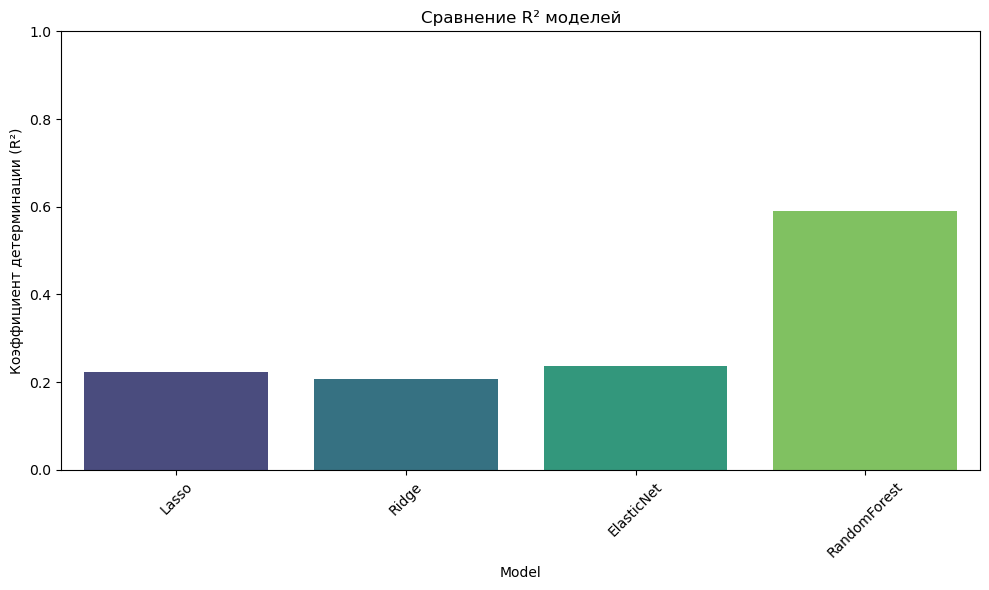

In [8]:
# Обновленная функция evaluate_model для расчета R²
def evaluate_model(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mse)
    return {'MSE': mse, 'MAE': mae, 'R2': r2, 'RMSE': rmse}

# В секции после обучения каждой модели добавляем расчет R²:

# Для Lasso
lasso_metrics = evaluate_model(y, lasso_opt.predict(X_scaled))
print(f"Лучшие параметры Lasso: {lasso_opt.best_params_}")
print(f"Лучший MSE: {-lasso_opt.best_score_:.4f}")
print(f"R²: {lasso_metrics['R2']:.4f}")

# Для Ridge
ridge_metrics = evaluate_model(y, ridge_opt.predict(X_scaled))
print(f"Лучшие параметры Ridge: {ridge_opt.best_params_}")
print(f"Лучший MSE: {-ridge_opt.best_score_:.4f}")
print(f"R²: {ridge_metrics['R2']:.4f}")

# Для ElasticNet
elastic_metrics = evaluate_model(y, elastic_opt.predict(X_scaled))
print(f"Лучшие параметры ElasticNet: {elastic_opt.best_params_}")
print(f"Лучший MSE: {-elastic_opt.best_score_:.4f}")
print(f"R²: {elastic_metrics['R2']:.4f}")

# Для Random Forest
rf_metrics = evaluate_model(y, rf_opt.predict(X))
print(f"Лучшие параметры Random Forest: {rf_opt.best_params_}")
print(f"Лучший MSE: {-rf_opt.best_score_:.4f}")
print(f"R²: {rf_metrics['R2']:.4f}")

# Обновляем таблицу сравнения моделей
results = pd.DataFrame({
    'Model': ['Lasso', 'Ridge', 'ElasticNet', 'RandomForest'],
    'Best MSE': [
        -lasso_opt.best_score_,
        -ridge_opt.best_score_,
        -elastic_opt.best_score_,
        -rf_opt.best_score_
    ],
    'R2': [
        lasso_metrics['R2'],
        ridge_metrics['R2'],
        elastic_metrics['R2'],
        rf_metrics['R2']
    ],
    'Nested CV MSE': [lasso_mean, np.nan, np.nan, rf_mean],
    'Nested CV Std': [lasso_std, np.nan, np.nan, rf_std]
})

print("\nСравнение производительности моделей:")
print(results.sort_values('R2', ascending=False))

# Визуализация R²
plt.figure(figsize=(10, 6))
sns.barplot(data=results, x='Model', y='R2', palette='viridis')
plt.title('Сравнение R² моделей')
plt.ylim(0, 1)
plt.ylabel('Коэффициент детерминации (R²)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

После ряда экспериментов с тренировкой моделей мы получили результаты по коэффициенту детерминации каждой из них. Наилучшей считается случайный лес, так как он наиболее точен. 60% для финансовых данных является хорошим результатом, так как финансовые данные сильно зашумлены.

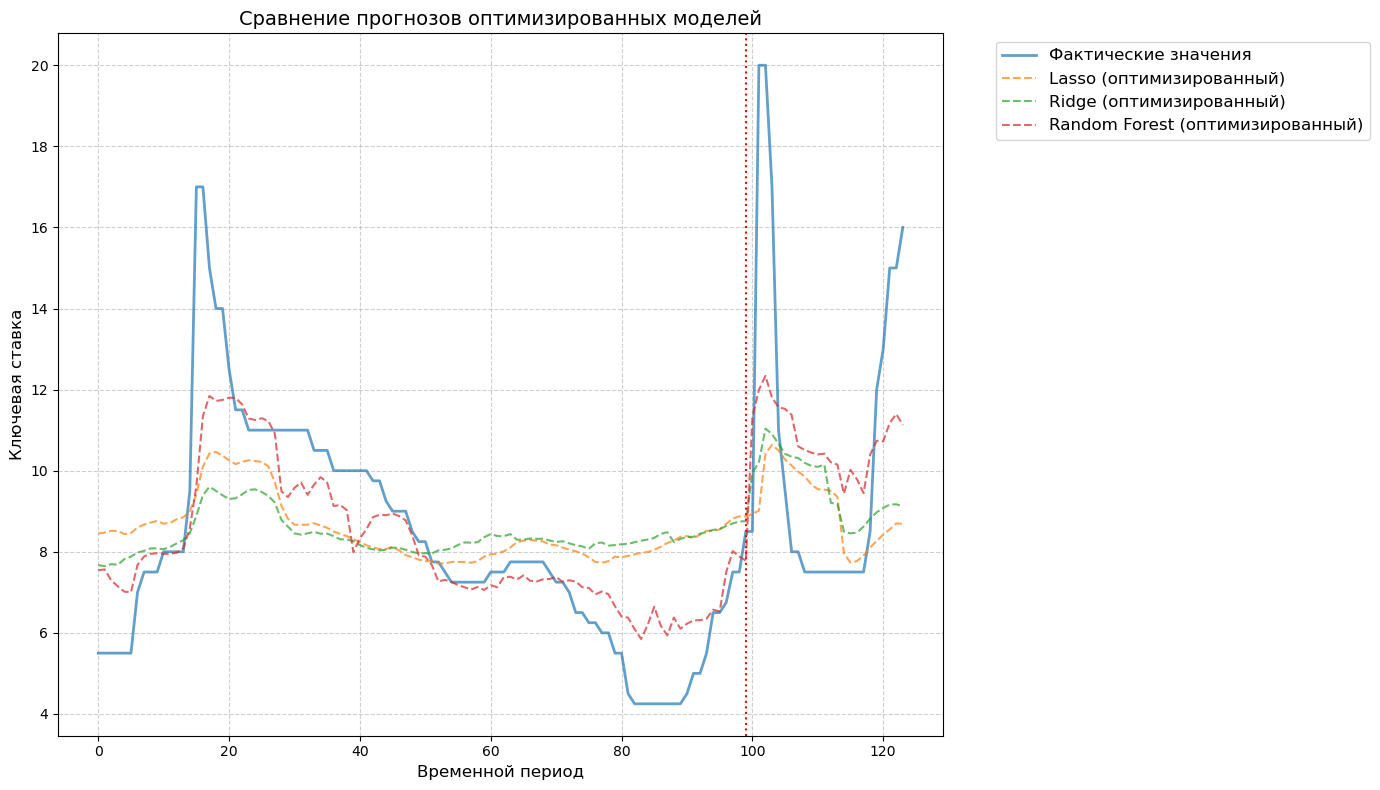

In [9]:
plt.figure(figsize=(14, 8))

# Фактические значения
plt.plot(y.values, label='Фактические значения', alpha=0.7, linewidth=2)

# Предсказания моделей (используем лучшие версии после оптимизации)
plt.plot(best_lasso.predict(scaler.transform(X)), '--', label='Lasso (оптимизированный)', alpha=0.7)
plt.plot(best_ridge.predict(scaler.transform(X)), '--', label='Ridge (оптимизированный)', alpha=0.7)
plt.plot(best_rf.predict(X), '--', label='Random Forest (оптимизированный)', alpha=0.7)

# Настройка графика
plt.title("Сравнение прогнозов оптимизированных моделей", fontsize=14)
plt.xlabel("Временной период", fontsize=12)
plt.ylabel("Ключевая ставка", fontsize=12)
plt.legend(fontsize=12, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)

# Добавим вертикальную линию для разделения train/test
train_size = int(len(X) * 0.8)  # 80% train / 20% test
plt.axvline(x=train_size, color='red', linestyle=':', label='Разделение train/test')

plt.tight_layout()
plt.show()

На изображении выше представлено поведение каждой из модели в изменяющихся условиях. Стоит отметить, что каждая из них сглаживает исходные данные. Это связано с порой радикальными мерами со стороны ЦБ, чтобы снизить инфляционные ожидания.

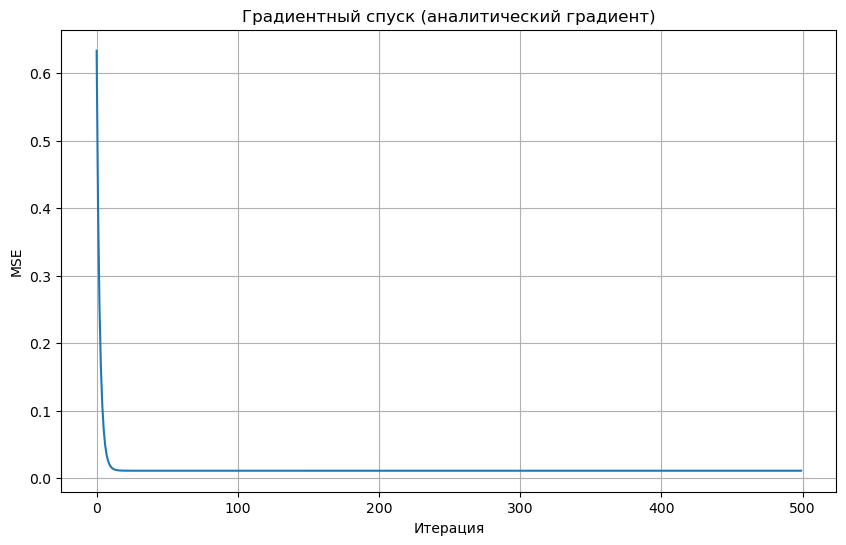

Найденные параметры: weights=[ 0.81951122 -0.5331701 ], bias=-0.00
Истинные параметры: weights=[ 2.5 -1.8], bias=3.7


In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import torch
from sklearn.preprocessing import StandardScaler

# 1. Подготовка данных
np.random.seed(42)
X = np.random.rand(100, 2) * 10
true_weights = np.array([2.5, -1.8])
true_bias = 3.7
y = X.dot(true_weights) + true_bias + np.random.normal(0, 1, 100)

# Масштабирование
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
y_scaled = (y - y.mean()) / y.std()

# 2. Функция потерь и градиент
def mse_loss(w, X, y):
    return np.mean((X.dot(w[:-1]) + w[-1] - y) ** 2)

def mse_gradient(w, X, y):
    """Аналитический расчет градиента MSE"""
    error = X.dot(w[:-1]) + w[-1] - y
    grad_weights = 2 * X.T.dot(error) / len(X)
    grad_bias = 2 * np.mean(error)
    return np.concatenate([grad_weights, [grad_bias]])

# 3. Градиентный спуск
def gradient_descent(X, y, grad_func, lr=0.01, epochs=1000, batch_size=None):
    w = np.zeros(X.shape[1] + 1)  # +1 для bias
    losses = []
    
    for epoch in range(epochs):
        if batch_size is None:
            grad = grad_func(w, X, y)
        else:
            idx = np.random.choice(len(X), batch_size, replace=False)
            grad = grad_func(w, X[idx], y[idx])
        
        w -= lr * grad
        losses.append(mse_loss(w, X, y))
    
    return w, losses

# 4. Оптимизация
w, losses = gradient_descent(X_scaled, y_scaled, mse_gradient, lr=0.1, epochs=500)

# Визуализация
plt.figure(figsize=(10, 6))
plt.plot(losses)
plt.title("Градиентный спуск (аналитический градиент)")
plt.xlabel("Итерация")
plt.ylabel("MSE")
plt.grid()
plt.show()

print(f"Найденные параметры: weights={w[:-1]}, bias={w[-1]:.2f}")
print(f"Истинные параметры: weights={true_weights}, bias={true_bias}")

Первый признак (положительный вес):
Если это инфляция: ЦБ повышает ставку при росте инфляции (стандартная реакция).
Второй признак (отрицательный вес):
Если это цена нефти: рост нефти снижает ставку (возможно, из-за укрепления рубля и снижения инфляционного давления).